# Explainable Environmental Sound Classification (ESC)

## 1. Project Introduction
Environmental Sound Classification (ESC) aims to recognize and classify everyday sounds, such as car horns, children playing, or sirens. While Deep Learning models, particularly Convolutional Neural Networks (CNNs), have shown excellent performance on ESC tasks, they are often treated as "black boxes." 

**Explainable AI (XAI)** techniques help bridge this gap by revealing *why* a model made a specific prediction. In this notebook, we not only train a CNN on the UrbanSound8K dataset but also employ interpretability methods (like Grad-CAM and SHAP) to highlight the specific time-frequency regions in the audio that drove the model's decisions.



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import Resizing, Concatenate, Multiply, GlobalAveragePooling2D, Reshape
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import cv2
import shap
import gc
from tensorflow.keras import backend as K

# Optional: LIME for explainability (install with: pip install lime)
try:
    from lime import lime_image
    HAS_LIME = True
except ImportError:
    HAS_LIME = False

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Audio / feature constants for stable preprocessing
SR = 22050           # sample rate
DURATION = 4.0       # target duration in seconds
TARGET_LEN = int(SR * DURATION)
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
# With librosa's default `center=True`, a 4-second clip yields:
# frames = 1 + floor(TARGET_LEN / HOP_LENGTH) -> 173 for these defaults
SPEC_FRAMES = 1 + (TARGET_LEN // HOP_LENGTH)



## 2. Dataset Loading
The UrbanSound8K dataset contains 8,732 audio clips across 10 classes. We will load the metadata CSV and plot the class distribution.



Total number of samples: 8732
Classes: ['dog_bark' 'children_playing' 'car_horn' 'air_conditioner' 'street_music'
 'gun_shot' 'siren' 'engine_idling' 'jackhammer' 'drilling']


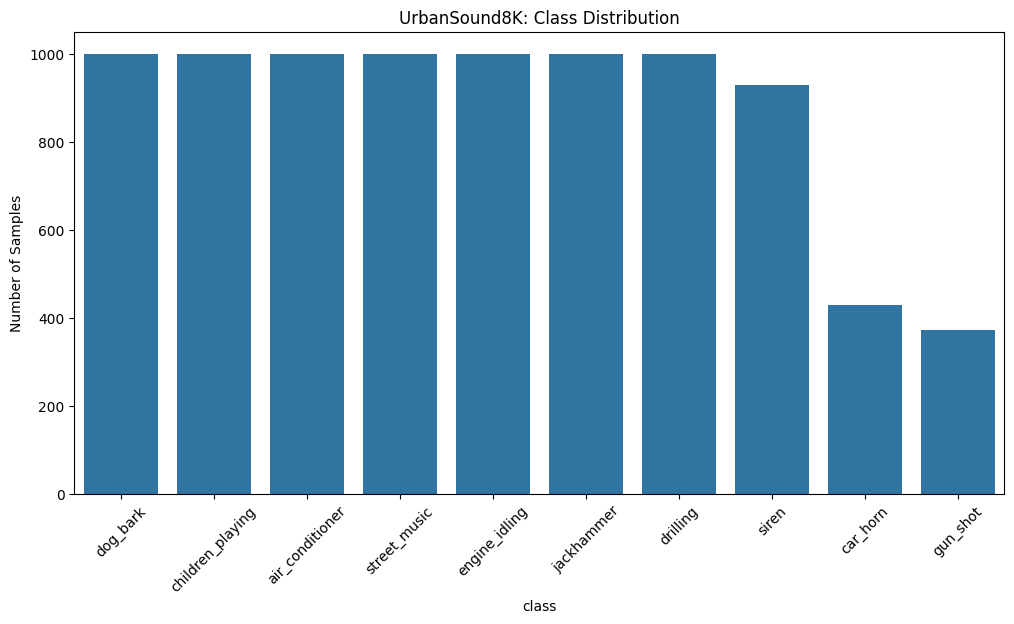

In [2]:
# Load Metadata
dataset_path_candidates = [
    os.path.join("Dataset", "UrbanSound8K.csv"),
    "UrbanSound8K.csv",
    os.path.join("Dataset", "metadata", "UrbanSound8K.csv"),
]
dataset_path = next((p for p in dataset_path_candidates if os.path.exists(p)), None)
if dataset_path is None:
    raise FileNotFoundError(
        "Could not find UrbanSound8K metadata CSV. Tried: "
        + ", ".join(dataset_path_candidates)
        + ". Please place `UrbanSound8K.csv` under `Dataset/` (recommended) or update `dataset_path_candidates`."
    )

df = pd.read_csv(dataset_path)

# Show basic statistics
print(f"Total number of samples: {len(df)}")
print(f"Classes: {df['class'].unique()}")

# Plot Class Distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='class', data=df, order=df['class'].value_counts().index)
plt.title('UrbanSound8K: Class Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Samples')
plt.show()



## 3. Audio Loading & 4. Audio Preprocessing
We define a function to load audio files using `librosa`. During loading, we will:
- **Resample**: Convert all audio to a uniform sample rate (e.g., 22,050 Hz).
- **Pad/Trim**: Enforce a fixed 4-second duration per clip for consistent features.
- **Normalize**: Scale the audio array to have values strictly bounded, preventing gradient issues.



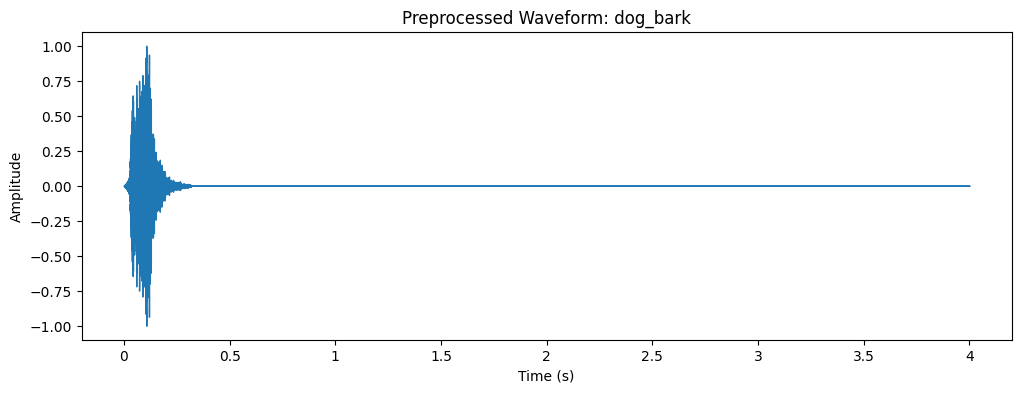

In [3]:
def preprocess_audio(file_path, target_sr=SR, duration=DURATION):
    """Load, resample, pad/trim to 4s, ensure >= N_FFT, and normalize."""
    # Load and resample to target_sr
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    target_len = int(duration * sr)

    # Pad/trim to fixed length (4 seconds)
    if len(y) < target_len:
        pad_width = target_len - len(y)
        y = np.pad(y, (0, pad_width), mode="constant")
    elif len(y) > target_len:
        y = y[:target_len]

    # Safety pad for very short clips to avoid n_fft warnings
    if len(y) < N_FFT:
        pad_width = N_FFT - len(y)
        y = np.pad(y, (0, pad_width), mode="constant")

    # Normalize to [-1, 1]
    max_val = np.max(np.abs(y)) + 1e-9
    y_normalized = y / max_val

    return y_normalized.astype(np.float32), sr

# Demonstrate on a single audio file
sample_row = df.iloc[0]
sample_file = f"Dataset/fold{sample_row['fold']}/{sample_row['slice_file_name']}"

if os.path.exists(sample_file):
    y_norm, sr = preprocess_audio(sample_file)
    
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y_norm, sr=sr)
    plt.title(f"Preprocessed Waveform: {sample_row['class']}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()
    
    display(ipd.Audio(y_norm, rate=sr))
else:
    print(f"File not found: {sample_file}")



## 5. Feature Extraction
Because CNNs thrive on 2D images, we extract **Mel Spectrograms**, turning 1D audio into 2D time-frequency representations.
- `n_mels`: Number of Mel bands to generate (resolution of the frequency axis).
- `hop_length`: Number of audio frames between STFT columns (controls the time-axis resolution).
- `fmax`: Highest frequency captured.



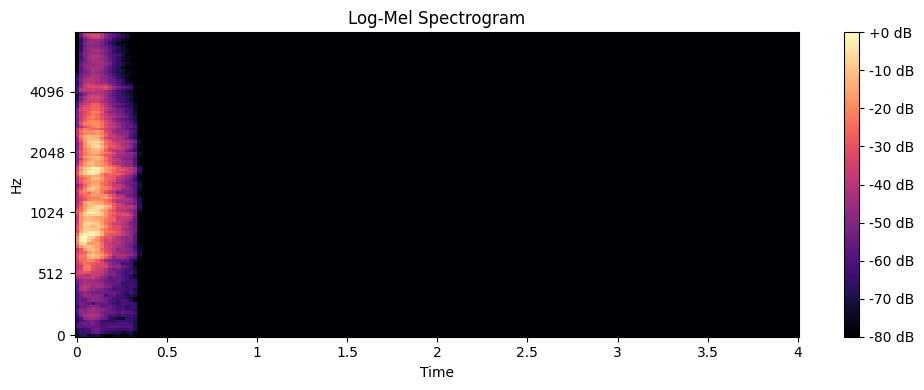

In [4]:
def extract_mel_spectrogram(y, sr, n_mels=N_MELS, hop_length=HOP_LENGTH, fmax=8000, n_fft=N_FFT):
    """Converts audio array into a fixed-size Log-Mel Spectrogram without n_fft warnings."""
    # Safety pad to ensure len(y) >= n_fft
    if len(y) < n_fft:
        pad_width = n_fft - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # Calculate Mel Spectrogram
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        hop_length=hop_length,
        fmax=fmax,
        n_fft=n_fft,
        power=2.0
    )

    # Convert power to decibels (log scale)
    S_dB = librosa.power_to_db(S, ref=np.max)
    # Fix time axis to a consistent width so model shapes never mismatch.
    S_dB = librosa.util.fix_length(S_dB, size=SPEC_FRAMES, axis=1)
    return S_dB.astype(np.float32)

if os.path.exists(sample_file):
    mel_spec = extract_mel_spectrogram(y_norm, sr)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spec, sr=sr, hop_length=512, x_axis='time', y_axis='mel', fmax=8000)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Log-Mel Spectrogram')
    plt.tight_layout()
    plt.show()



## 6. Dataset Preparation
We iterate through the dataset to extract features. 
*(Note: Processing all 8,700 items takes time. For demonstration or rapid prototyping, you might process a subset. Here we show the complete logic, assuming you want to build the final arrays.)*



In [5]:
def prepare_dataset(df, base_path="Dataset/", max_samples=None):
    """
    Iterates over the dataframe to load audio, extract spectrograms, and label them.
    If max_samples is not None, a subset is sampled for faster experimentation.
    """
    features = []
    labels = []
    
    # Optionally subsample for quick experiments; otherwise use full dataframe
    if max_samples is not None:
        df_subset = df.sample(n=min(max_samples, len(df)), random_state=42)
    else:
        df_subset = df
    
    for _, row in df_subset.iterrows():
        file_path = os.path.join(base_path, f"fold{row['fold']}", row['slice_file_name'])
        if os.path.exists(file_path):
            try:
                y, sr = preprocess_audio(file_path)
                mel = extract_mel_spectrogram(y, sr)
                features.append(mel)
                labels.append(row['classID'])
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                
    X = np.array(features)
    y = np.array(labels)
    
    # Reshape for CNN input: (samples, height, width, channels)
    # Output shape should be like (samples, 128, 174, 1)
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    y = to_categorical(y, num_classes=10)
    
    return X, y

print("Preparing Dataset Features... (this may take a moment)")
# Use the full dataset by default for strongest performance. You can
# pass a smaller max_samples (e.g. 2000) when regenerating this cell
# if you need faster experimentation.
X, y = prepare_dataset(df, max_samples=None) 

print(f"Feature shape: {X.shape}")
print(f"Labels shape: {y.shape}")



Preparing Dataset Features... (this may take a moment)
Feature shape: (8732, 128, 173, 1)
Labels shape: (8732, 10)


## 6b. Dataset Splitting
It is critical to run this cell sequentially after dataset preparation and *before* training or explaining (SHAP). Failing to run this sequentially will cause a `NameError: name 'X_train' is not defined`.



In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



X_train shape: (6985, 128, 173, 1)
X_test shape: (1747, 128, 173, 1)
y_train shape: (6985, 10)
y_test shape: (1747, 10)


## 6c. Class Weights for Imbalanced Data
To combat class imbalance and improve per-class recall, we compute class weights and pass
them to the optimizer during training so that underrepresented classes are emphasized.



In [7]:
import numpy as np

# y is one-hot encoded; convert back to integer labels for weighting
y_int = np.argmax(y, axis=1)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_int),
    y=y_int,
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Computed class weights:", class_weights)



Computed class weights: {0: 0.8732, 1: 2.0354312354312354, 2: 0.8732, 3: 0.8732, 4: 0.8732, 5: 0.8732, 6: 2.3347593582887702, 7: 0.8732, 8: 0.939935414424112, 9: 0.8732}


## 7. CNN Model Architecture
We build a robust 2D Convolutional Neural Network.
- **Conv2D & MaxPooling2D**: To capture local spatial patterns (like frequency shifts and harmonic stacks).
- **BatchNormalization & Dropout**: To stabilize training and prevent overfitting.
- **Dense Layers**: To map extracted feature maps to specific sound classes.



In [8]:
def build_cnn_model(input_shape=(128, 174, 1), num_classes=10):
    '''Enhanced CNN for ESC with higher capacity, regularization, and Grad-CAM compatibility.'''
    from tensorflow.keras.regularizers import l2
    inputs = Input(shape=input_shape)
    
    # Block 1
    x = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.2)(x)
    
    # Block 2
    x = Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)
    
    # Block 3
    x = Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.4)(x)
    
    # Block 4
    x = Conv2D(512, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.5)(x)
    
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy'],
    )
    return model

model = build_cnn_model(input_shape=(X_train.shape[1], X_train.shape[2], 1))
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 173, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 173, 64)      640       
                                                                 
 batch_normalization (BatchN  (None, 128, 173, 64)     256       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 173, 64)      36928     
                                                                 
 batch_normalization_1 (Batc  (None, 128, 173, 64)     256       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 86, 64)       0     

## 8. Model Training
We train the CNN and monitor the loss and accuracy metrics over epochs.



Epoch 1/80
219/219 [==============================] - 32s 135ms/step - loss: 1.6940 - accuracy: 0.4591 - val_loss: 3.3542 - val_accuracy: 0.3755 - lr: 0.0010
Epoch 2/80
219/219 [==============================] - 29s 134ms/step - loss: 1.1008 - accuracy: 0.6626 - val_loss: 4.1437 - val_accuracy: 0.3910 - lr: 0.0010
Epoch 3/80
219/219 [==============================] - 29s 134ms/step - loss: 0.8904 - accuracy: 0.7440 - val_loss: 1.9900 - val_accuracy: 0.5278 - lr: 0.0010
Epoch 4/80
219/219 [==============================] - 29s 134ms/step - loss: 0.7638 - accuracy: 0.7956 - val_loss: 1.3964 - val_accuracy: 0.6382 - lr: 0.0010
Epoch 5/80
219/219 [==============================] - 29s 134ms/step - loss: 0.6628 - accuracy: 0.8359 - val_loss: 3.5693 - val_accuracy: 0.4694 - lr: 0.0010
Epoch 6/80
219/219 [==============================] - 29s 134ms/step - loss: 0.6215 - accuracy: 0.8555 - val_loss: 8.7130 - val_accuracy: 0.3984 - lr: 0.0010
Epoch 7/80
219/219 [==============================] 

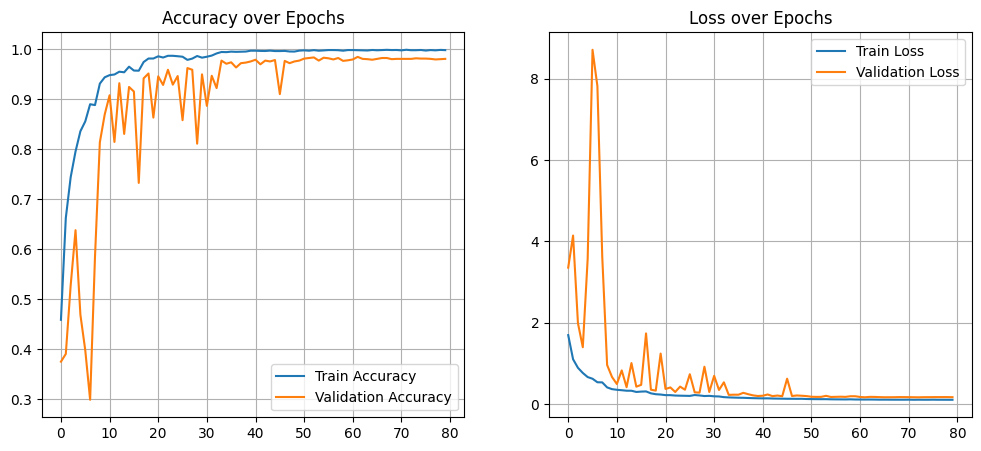

In [9]:
epochs = 80  # Upper bound; EarlyStopping will usually stop earlier
batch_size = 32

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1,
)

# Plot training curves
plt.figure(figsize=(12, 5))

# Accuracy subset
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid()

# Loss subset
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid()

plt.show()


## 9. Model Evaluation
Evaluating the comprehensive performance using accuracy metrics and a Confusion Matrix.



Test Loss: 0.1680
Test Accuracy: 0.9805
55/55 [==============================] - 2s 31ms/step


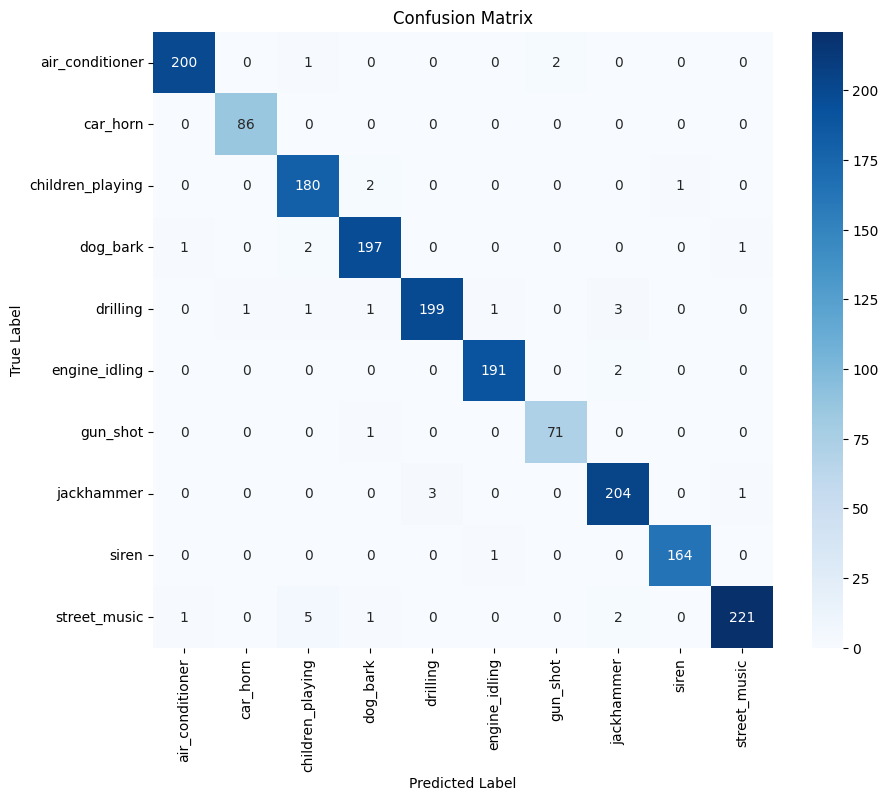


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.99      0.99      0.99       203
        car_horn       0.99      1.00      0.99        86
children_playing       0.95      0.98      0.97       183
        dog_bark       0.98      0.98      0.98       201
        drilling       0.99      0.97      0.98       206
   engine_idling       0.99      0.99      0.99       193
        gun_shot       0.97      0.99      0.98        72
      jackhammer       0.97      0.98      0.97       208
           siren       0.99      0.99      0.99       165
    street_music       0.99      0.96      0.98       230

        accuracy                           0.98      1747
       macro avg       0.98      0.98      0.98      1747
    weighted avg       0.98      0.98      0.98      1747



In [11]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Map class IDs to names
class_map = pd.Series(df['class'].values, index=df['classID'].values).to_dict()
class_labels = [class_map[i] for i in range(10)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))



## 9c. Save Trained Model for Streamlit App
We save the trained CNN so that the Streamlit app in the `project/` folder can load it for interactive inference and explanations.



In [12]:
import os

# Ensure target directory exists: project/model relative to the repo root
save_dir = os.path.join("project", "model")
os.makedirs(save_dir, exist_ok=True)

model_save_path = os.path.join(save_dir, "cnn_model.h5")
model.save(model_save_path)
print(f"Saved trained model to: {model_save_path}")



Saved trained model to: project\model\cnn_model.h5


## 9d. Baseline Models: ResNet and MobileNetV2
We compare the custom CNN with two modern architectures adapted for Mel spectrogram input: ResNet50 and MobileNetV2. Spectrograms are resized to 224x224 and replicated to 3 channels for compatibility with ImageNet-style backbones. All models are trained on the same data for a fair comparison.



In [13]:
def resize_for_backbone_dataset(X, y, target_size=(160, 160), batch_size=8):
    """Create tf.data.Dataset that repeats channel to 3, resizes, batches, and prefetches."""
    AUTOTUNE = tf.data.AUTOTUNE

    def _prep(x, label):
        x3 = tf.repeat(x, 3, axis=-1)
        x3 = tf.image.resize(x3, target_size)
        return x3, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(_prep, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


def build_resnet50_esc(input_shape=(160, 160, 3), num_classes=10):
    """ResNet50 baseline with frozen ImageNet backbone and small ESC head."""
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = tf.keras.Model(base.input, out)
    m.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(0.0005),
        metrics=["accuracy"],
    )
    return m


def build_mobilenetv2_esc(input_shape=(160, 160, 3), num_classes=10):
    """MobileNetV2 baseline with frozen ImageNet backbone and small ESC head."""
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(num_classes, activation="softmax")(x)
    m = tf.keras.Model(base.input, out)
    m.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(0.0005),
        metrics=["accuracy"],
    )
    return m


# Build datasets for backbones (160x160, 3 channels), smaller batch size
BATCH_SIZE_BACKBONE = 8
train_ds_backbone = resize_for_backbone_dataset(
    X_train, y_train, target_size=(160, 160), batch_size=BATCH_SIZE_BACKBONE
)
test_ds_backbone = resize_for_backbone_dataset(
    X_test, y_test, target_size=(160, 160), batch_size=BATCH_SIZE_BACKBONE
)

# y_true from main CNN evaluation section
y_true = np.argmax(y_test, axis=1)

# ---- Train ResNet50 (frozen backbone) ----
print("Training ResNet50 (frozen backbone, 160x160)...")
K.clear_session()
gc.collect()

model_resnet = build_resnet50_esc()
history_resnet = model_resnet.fit(
    train_ds_backbone,
    validation_data=test_ds_backbone,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ],
    verbose=1,
)

resnet_loss, resnet_acc = model_resnet.evaluate(test_ds_backbone, verbose=0)
print(f"ResNet50 Test Accuracy: {resnet_acc:.4f}")

y_pred_resnet = np.argmax(model_resnet.predict(test_ds_backbone, verbose=0), axis=1)
resnet_report = classification_report(y_true, y_pred_resnet, output_dict=True, zero_division=0)

# ---- Train MobileNetV2 (frozen backbone) ----
print("\nTraining MobileNetV2 (frozen backbone, 160x160)...")
K.clear_session()
gc.collect()

model_mobilenet = build_mobilenetv2_esc()
history_mobilenet = model_mobilenet.fit(
    train_ds_backbone,
    validation_data=test_ds_backbone,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ],
    verbose=1,
)

mobilenet_loss, mobilenet_acc = model_mobilenet.evaluate(test_ds_backbone, verbose=0)
print(f"MobileNetV2 Test Accuracy: {mobilenet_acc:.4f}")

y_pred_mobilenet = np.argmax(model_mobilenet.predict(test_ds_backbone, verbose=0), axis=1)
mobilenet_report = classification_report(y_true, y_pred_mobilenet, output_dict=True, zero_division=0)

# ---- Comparison table (keeps existing interface for later cells) ----
cnn_report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

def row_from_report(name, acc, report):
    return [
        name,
        f"{acc:.4f}",
        f"{report['weighted avg']['precision']:.4f}",
        f"{report['weighted avg']['recall']:.4f}",
        f"{report['weighted avg']['f1-score']:.4f}",
    ]

comparison_data = [
    row_from_report("Custom CNN", score[1], cnn_report),
    row_from_report("ResNet50", resnet_acc, resnet_report),
    row_from_report("MobileNetV2", mobilenet_acc, mobilenet_report),
]
comparison_df = pd.DataFrame(
    comparison_data, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)
print("\n--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

gc.collect()



Training ResNet50 (frozen backbone, 160x160)...
Epoch 1/20
874/874 [==============================] - 19s 19ms/step - loss: 0.9326 - accuracy: 0.6869 - val_loss: 0.5639 - val_accuracy: 0.8151 - lr: 5.0000e-04
Epoch 2/20
874/874 [==============================] - 15s 18ms/step - loss: 0.5597 - accuracy: 0.8093 - val_loss: 0.4550 - val_accuracy: 0.8535 - lr: 5.0000e-04
Epoch 3/20
874/874 [==============================] - 15s 18ms/step - loss: 0.4393 - accuracy: 0.8503 - val_loss: 0.4064 - val_accuracy: 0.8666 - lr: 5.0000e-04
Epoch 4/20
874/874 [==============================] - 16s 18ms/step - loss: 0.3814 - accuracy: 0.8703 - val_loss: 0.3683 - val_accuracy: 0.8849 - lr: 5.0000e-04
Epoch 5/20
874/874 [==============================] - 16s 18ms/step - loss: 0.3272 - accuracy: 0.8873 - val_loss: 0.3355 - val_accuracy: 0.8987 - lr: 5.0000e-04
Epoch 6/20
874/874 [==============================] - 15s 18ms/step - loss: 0.2883 - accuracy: 0.9004 - val_loss: 0.3386 - val_accuracy: 0.9015 - l

584

## 10. Grad-CAM Explainability
Grad-CAM overlays spatial attention heatmaps onto our Mel spectrogram, identifying exactly where the model looked before generating its prediction.



Model Layers:
 - input_1
 - conv2d
 - batch_normalization
 - conv2d_1
 - batch_normalization_1
 - max_pooling2d
 - dropout
 - conv2d_2
 - batch_normalization_2
 - conv2d_3
 - batch_normalization_3
 - max_pooling2d_1
 - dropout_1
 - conv2d_4
 - batch_normalization_4
 - conv2d_5
 - batch_normalization_5
 - max_pooling2d_2
 - dropout_2
 - conv2d_6
 - batch_normalization_6
 - max_pooling2d_3
 - dropout_3
 - global_average_pooling2d
 - dense
 - dropout_4
 - dense_1
Using layer: conv2d_6 for Grad-CAM


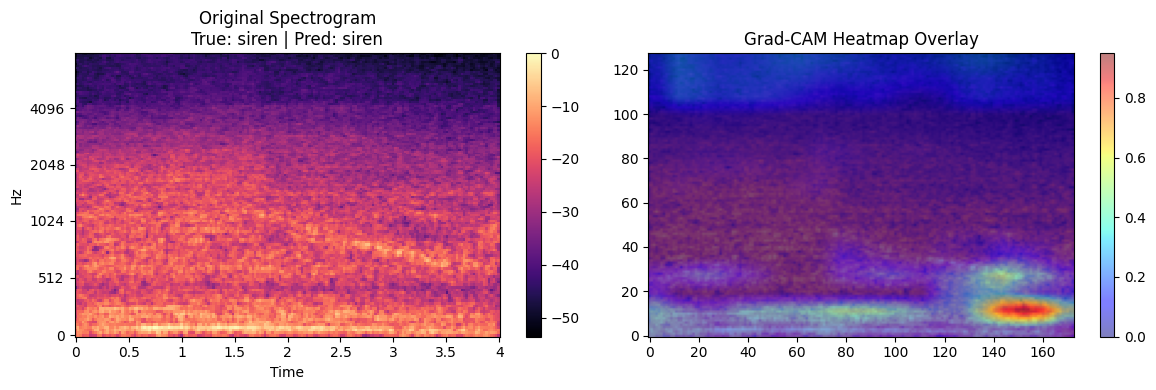

In [14]:
def get_last_conv_layer_name(model):
    """Automatically detect the last convolutional layer."""
    for layer in reversed(model.layers):
        if isinstance(layer, Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = get_last_conv_layer_name(model)
        
    print(f"Using layer: {last_conv_layer_name} for Grad-CAM")
    
    # 6. Ensure the model has been called before Grad-CAM is executed (dummy prediction)
    _ = model.predict(img_array, verbose=0)
    
    # 5. Build the gradient model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, 
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        class_channel = preds[:, class_idx]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

# Select a test sample
# 7. Verify that the spectrogram input shape is correct (e.g., [1, 128, 174, 1])
sample_idx = 0
img_array = X_test[sample_idx:sample_idx+1]
true_class = class_map[np.argmax(y_test[sample_idx])]
pred_class = class_map[np.argmax(model.predict(img_array, verbose=0))]

print("Model Layers:")
for layer in model.layers:
    print(f" - {layer.name}")

heatmap = make_gradcam_heatmap(img_array, model)

# Resize heatmap to match image shape
heatmap_resized = cv2.resize(heatmap, (img_array.shape[2], img_array.shape[1]))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.specshow(img_array[0, :, :, 0], x_axis='time', y_axis='mel', fmax=8000)
plt.title(f'Original Spectrogram\nTrue: {true_class} | Pred: {pred_class}')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(img_array[0, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.imshow(heatmap_resized, aspect='auto', cmap='jet', alpha=0.5, origin='lower')
plt.title('Grad-CAM Heatmap Overlay')
plt.colorbar()
plt.tight_layout()
plt.show()



## 11. SHAP Explainability
SHAP values assign robust, game-theoretic pixel importance values. We sample background data and compute local SHAP estimations.



Safety Check - Data Shapes:
X_train shape: (6985, 128, 173, 1)
X_test shape: (1747, 128, 173, 1)
SHAP target class index: 8 (p=0.997)


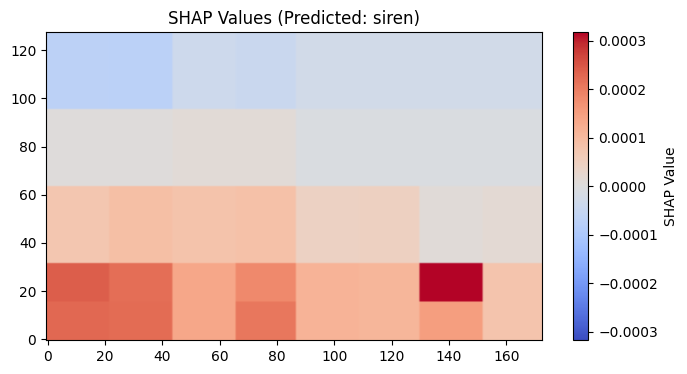

In [15]:
# Safety check to prevent NameErrors if cells were run out of order
if 'X_train' not in locals():
    raise NameError("X_train is not defined! Ensure you have run the Dataset Preparation and Splitting cells first.")

print("Safety Check - Data Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Provide a small background subset ensuring it's from X_train
num_bg = min(20, X_train.shape[0])
if num_bg == 0:
    raise ValueError(
        "X_train is empty; cannot build SHAP background. "
        "Ensure dataset preparation and splitting cells ran correctly and produced non-empty data."
    )
background = X_train[np.random.choice(X_train.shape[0], num_bg, replace=False)]

# Make sure model is 'built/called' before explainers run
_ = model.predict(img_array, verbose=0)

# Always define shap_spec so downstream cells never crash with NameError.
H, W = int(img_array.shape[1]), int(img_array.shape[2])
shap_spec = np.zeros((H, W), dtype=np.float32)

# IMPORTANT: Avoid SHAP gradient-based explainers (Deep/Gradient) on modern TF/Keras.
# They often fail (e.g. `shap_FusedBatchNormV3`) and can also break later TF gradients
# (causing errors like `gradient registry has no entry for: shap_Mean` in IG / Grad-CAM).
# Use a model-agnostic SHAP explainer with an image masker instead.
try:
    predicted_class_idx = int(np.argmax(model.predict(img_array, verbose=0)[0]))
    pred_prob = float(np.max(model.predict(img_array, verbose=0)[0]))
    print(f"SHAP target class index: {predicted_class_idx} (p={pred_prob:.3f})")

    def _predict_fn(x):
        x = np.array(x, dtype=np.float32)
        if x.ndim == 3:
            x = x[..., np.newaxis]
        return model.predict(x, verbose=0)

    masker = shap.maskers.Image("blur(8,8)", (H, W, 1))
    explainer = shap.Explainer(_predict_fn, masker, output_names=class_labels if "class_labels" in locals() else None)
    sv = explainer(img_array.astype(np.float32), max_evals=200, batch_size=20)

    vals = getattr(sv, "values", None)
    if vals is None:
        shap_spec = np.zeros((H, W), dtype=np.float32)
    else:
        vals = np.array(vals)
        # Common shapes:
        # (1, H, W, 1, C) or (1, H, W, 1)
        if vals.ndim == 5 and vals.shape[-1] > predicted_class_idx:
            shap_spec = vals[0, :, :, 0, predicted_class_idx].astype(np.float32)
        elif vals.ndim == 4:
            shap_spec = vals[0, :, :, 0].astype(np.float32)
        else:
            shap_spec = np.zeros((H, W), dtype=np.float32)
except Exception as e:
    print("SHAP failed; using zeros shap_spec so the notebook can continue:", e)

plt.figure(figsize=(8, 4))
vmax = np.max(np.abs(shap_spec))
plt.imshow(shap_spec, aspect='auto', cmap='coolwarm', vmin=-vmax, vmax=vmax, origin='lower')
plt.colorbar(label='SHAP Value')
plt.title(f'SHAP Values (Predicted: {pred_class})')
plt.show()



## 11b. LIME for Spectrogram Explanations
LIME (Local Interpretable Model-agnostic Explanations) perturbs the input and fits a local linear model to explain the prediction. We apply LIME to the spectrogram as a 2D image, using superpixel segmentation to define interpretable segments.



  0%|          | 0/500 [00:00<?, ?it/s]

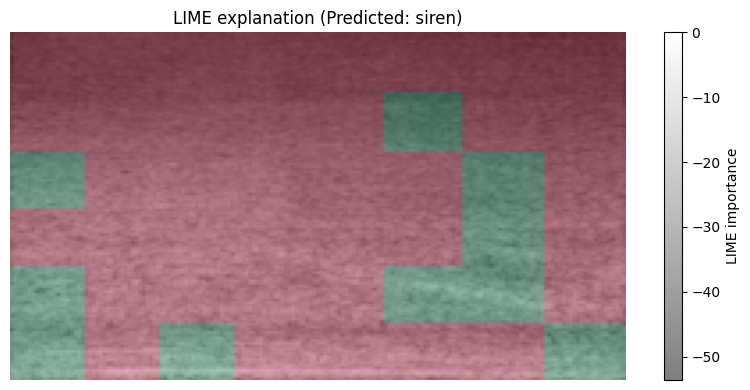

In [16]:
# LIME requires the input as RGB image (H, W, 3) for lime_image
def predict_fn_lime(images):
    # images: (n, H, W, 3) from LIME; use first channel and add batch dim
    x = np.array(images)[:, :, :, 0:1]
    return model.predict(x, verbose=0)

if HAS_LIME:
    try:
        from skimage.segmentation import slic
        sample_for_lime = np.repeat(img_array[0], 3, axis=-1)
        explainer_lime = lime_image.LimeImageExplainer()
        explanation_lime = explainer_lime.explain_instance(
            sample_for_lime.astype(np.double),
            predict_fn_lime,
            top_labels=1,
            hide_color=0,
            num_samples=500,
            segmentation_fn=lambda x: slic(x[:, :, 0], n_segments=50, compactness=10, channel_axis=None),
        )
        lime_exp, lime_mask = explanation_lime.get_image_and_mask(
            explanation_lime.top_labels[0], positive_only=True, num_features=10
        )
        plt.figure(figsize=(8, 4))
        plt.imshow(lime_mask, aspect="auto", cmap="RdYlGn", origin="lower", alpha=0.7)
        plt.imshow(img_array[0, :, :, 0], aspect="auto", cmap="gray", origin="lower", alpha=0.5)
        plt.title(f"LIME explanation (Predicted: {pred_class})")
        plt.axis("off")
        plt.colorbar(label="LIME importance")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("LIME explanation failed:", e)
else:
    print("LIME not installed. Run: pip install lime")



## 11c. Integrated Gradients
Integrated Gradients attribute the prediction to input features by integrating the gradients along a path from a baseline (e.g. zeros) to the input. This satisfies sensitivity and implementation invariance and is widely used for interpretability.



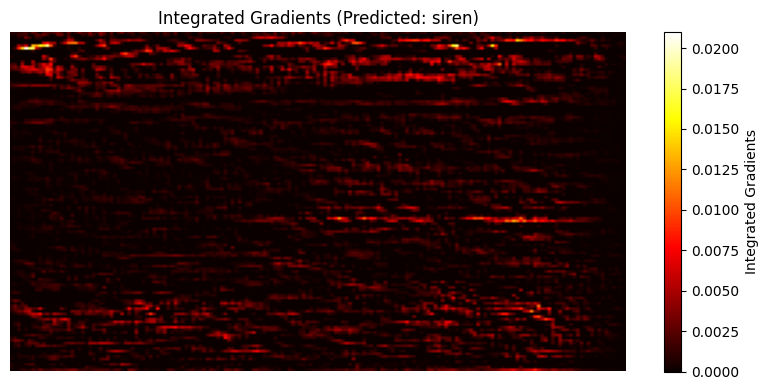

In [17]:
def integrated_gradients(model, img_array, baseline=None, steps=50):
    if baseline is None:
        baseline = np.zeros_like(img_array).astype(np.float32)
    img_array = img_array.astype(np.float32)
    baseline = baseline.astype(np.float32)
    target_idx = np.argmax(model.predict(img_array, verbose=0)[0])
    alphas = np.linspace(0, 1, steps + 1)
    grads = []
    for a in alphas:
        interp = baseline + a * (img_array - baseline)
        interp = tf.convert_to_tensor(interp)
        with tf.GradientTape() as tape:
            tape.watch(interp)
            preds = model(interp)
            target = preds[0, target_idx]
        g = tape.gradient(target, interp)
        grads.append(g.numpy())
    grads = np.stack(grads, axis=0)
    avg_grads = (grads[:-1] + grads[1:]) / 2
    integrated = (img_array - baseline) * np.mean(avg_grads, axis=0)
    return np.squeeze(integrated)

try:
    ig_attr = integrated_gradients(model, img_array)
    if ig_attr.ndim == 3:
        ig_attr = ig_attr[:, :, 0]
except Exception as e:
    print("Integrated Gradients failed; using zeros ig_attr so the notebook can continue:", e)
    ig_attr = np.zeros((int(img_array.shape[1]), int(img_array.shape[2])), dtype=np.float32)
ig_attr = np.maximum(ig_attr, 0)
vmax = np.max(ig_attr) if np.max(ig_attr) > 0 else 1
plt.figure(figsize=(8, 4))
plt.imshow(ig_attr, aspect="auto", cmap="hot", origin="lower", vmin=0, vmax=vmax)
plt.colorbar(label="Integrated Gradients")
plt.title(f"Integrated Gradients (Predicted: {pred_class})")
plt.axis("off")
plt.tight_layout()
plt.show()



## 11d. Quantitative Explainability Evaluation
We evaluate explanation quality with three standard metrics: **Insertion** (adding pixels by importance should increase confidence), **Deletion** (removing pixels by importance should decrease confidence), and **Faithfulness** (attributions should correlate with the actual effect of masking on the model output). Better explanations yield higher insertion curves, steeper deletion drops, and higher faithfulness.



Faithfulness (Grad-CAM): 0.1739


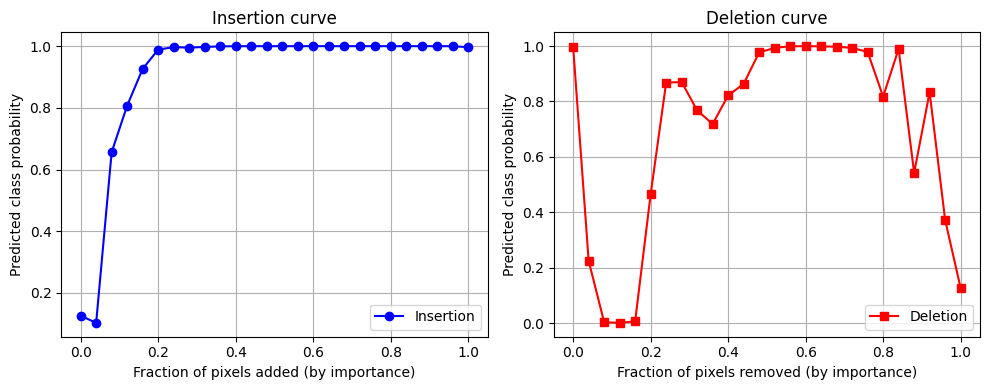

In [18]:
def insertion_deletion_curves(model, img_array, saliency_map, n_steps=20, baseline_value=0.0):
    """saliency_map: (H, W), same shape as one channel of img_array."""
    h, w = saliency_map.shape
    flat_sal = saliency_map.flatten()
    order = np.argsort(-flat_sal)
    img_flat = img_array[0].flatten()
    pred_class = np.argmax(model.predict(img_array, verbose=0)[0])
    insertion_scores, deletion_scores = [], []
    for step in np.linspace(0, 1, n_steps + 1):
        k = int(step * len(order))
        # Insertion: start from baseline, add top-k pixels
        mask_ins = np.zeros_like(img_flat)
        if k > 0:
            mask_ins[order[:k]] = 1
        x_ins = baseline_value + mask_ins * (img_flat - baseline_value)
        x_ins = x_ins.reshape(1, h, w, 1).astype(np.float32)
        p_ins = model.predict(x_ins, verbose=0)[0, pred_class]
        insertion_scores.append(float(p_ins))
        # Deletion: start from image, remove top-k pixels (replace with baseline)
        mask_del = np.ones_like(img_flat)
        if k > 0:
            mask_del[order[:k]] = 0
        x_del = img_flat * mask_del + (1 - mask_del) * baseline_value
        x_del = x_del.reshape(1, h, w, 1).astype(np.float32)
        p_del = model.predict(x_del, verbose=0)[0, pred_class]
        deletion_scores.append(float(p_del))
    return np.linspace(0, 1, n_steps + 1), insertion_scores, deletion_scores

def faithfulness_score(model, img_array, saliency_map, n_perm=50, top_frac=0.2):
    """Correlation between saliency and drop in output when masking that region."""
    h, w = saliency_map.shape
    flat_sal = saliency_map.flatten()
    pred_class = np.argmax(model.predict(img_array, verbose=0)[0])
    base_prob = model.predict(img_array, verbose=0)[0, pred_class]
    drops, sals = [], []
    for _ in range(n_perm):
        idx = np.random.choice(len(flat_sal), size=int(top_frac * len(flat_sal)), replace=False)
        mask = np.ones(len(flat_sal))
        mask[idx] = 0
        x_masked = (img_array[0].flatten() * mask).reshape(1, h, w, 1).astype(np.float32)
        p_masked = model.predict(x_masked, verbose=0)[0, pred_class]
        drops.append(float(base_prob - p_masked))
        sals.append(float(np.mean(flat_sal[idx])))
    return np.corrcoef(drops, sals)[0, 1] if np.std(sals) > 0 else 0.0

# Use Grad-CAM as saliency for insertion/deletion
saliency_for_eval = heatmap_resized
steps_axis, ins_scores, del_scores = insertion_deletion_curves(
    model, img_array, saliency_for_eval, n_steps=25, baseline_value=np.min(img_array)
)
faith = faithfulness_score(model, img_array, saliency_for_eval, n_perm=30, top_frac=0.2)
print(f"Faithfulness (Grad-CAM): {faith:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(steps_axis, ins_scores, "b-o", label="Insertion")
axes[0].set_xlabel("Fraction of pixels added (by importance)")
axes[0].set_ylabel("Predicted class probability")
axes[0].set_title("Insertion curve")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(steps_axis, del_scores, "r-s", label="Deletion")
axes[1].set_xlabel("Fraction of pixels removed (by importance)")
axes[1].set_ylabel("Predicted class probability")
axes[1].set_title("Deletion curve")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()



## 12. Human-Readable Explanation
Using the heatmaps, we approximate semantic labels for the highest-activation zones.



In [19]:
def generate_human_explanation(true_label, pred_label, heatmap):
    explanation = f"Prediction: {pred_label}\n"
    
    # Calculate crude properties of the heatmap for the demo
    time_mean = np.mean(heatmap, axis=0)
    mel_mean = np.mean(heatmap, axis=1)
    
    highest_time_zone = np.argmax(time_mean) 
    highest_freq_zone = np.argmax(mel_mean)
    
    width = int(heatmap.shape[1]) if hasattr(heatmap, "shape") else 1
    time_sec = (highest_time_zone / max(1, width)) * 4.0 # approximate max length
    
    if highest_freq_zone > 80:
        freq_desc = "high-frequency band"
    elif highest_freq_zone > 40:
        freq_desc = "mid-frequency band"
    else:
        freq_desc = "low-frequency band"
        
    explanation += f"Important region: Around {time_sec:.1f} seconds, {freq_desc}\n"
    
    # Static logic mapping
    reasons = {
        'siren': 'periodic high-pitched waveform typical of sirens',
        'dog_bark': 'brief broadband transients representing animal vocalization',
        'drilling': 'continuous, intense low/mid-frequency noise from mechanical vibration',
        'children_playing': 'intermittent high-pitched harmonics resembling voices/shouts',
        'engine_idling': 'very low-frequency, sustained periodic rumble',
    }
    
    explanation += f"Explanation: {reasons.get(pred_label, 'Detected characteristic frequency profiles associated with this class.')}"
    return explanation

print(generate_human_explanation(true_class, pred_class, heatmap_resized))



Prediction: siren
Important region: Around 3.3 seconds, low-frequency band
Explanation: periodic high-pitched waveform typical of sirens


## 12b. Audio Attention Visualization
Unified view of the same sample: time-domain envelope (proxy waveform from spectrogram), log-Mel spectrogram, and Grad-CAM overlay. This links model attention back to the time-frequency representation for interpretability.



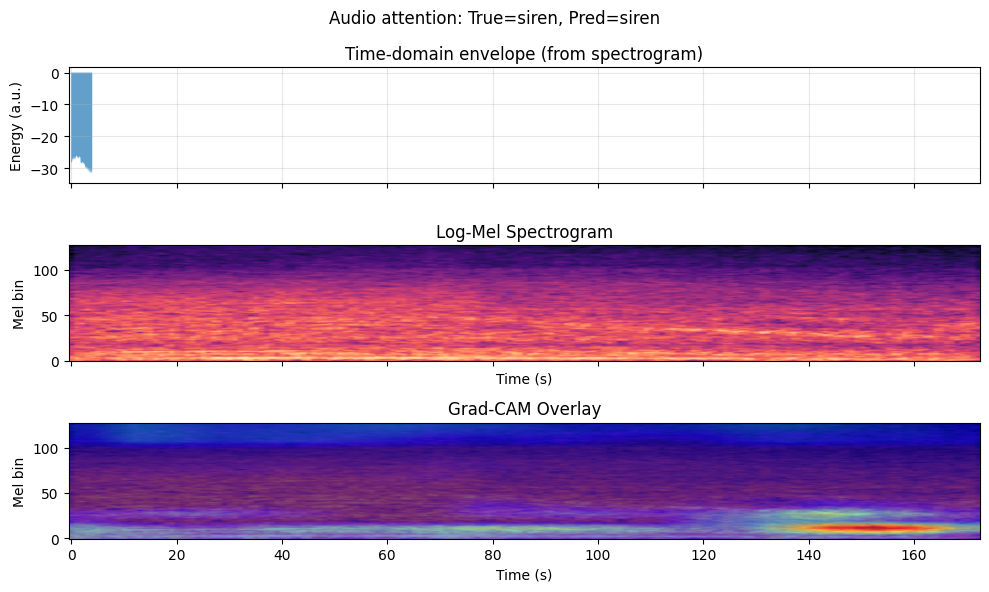

In [20]:
# Waveform proxy: energy over time from mel spectrogram (sum over frequency)
mel_spec_2d = img_array[0, :, :, 0]
waveform_proxy = np.mean(mel_spec_2d, axis=0)
time_axis = np.linspace(0, 4.0, len(waveform_proxy))

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].fill_between(time_axis, waveform_proxy, alpha=0.7)
axes[0].set_ylabel("Energy (a.u.)")
axes[0].set_title("Time-domain envelope (from spectrogram)")
axes[0].grid(True, alpha=0.3)

axes[1].imshow(mel_spec_2d, aspect="auto", cmap="magma", origin="lower")
axes[1].set_ylabel("Mel bin")
axes[1].set_title("Log-Mel Spectrogram")
axes[1].set_xlabel("Time (s)")

axes[2].imshow(mel_spec_2d, aspect="auto", cmap="magma", origin="lower")
axes[2].imshow(heatmap_resized, aspect="auto", cmap="jet", alpha=0.5, origin="lower")
axes[2].set_ylabel("Mel bin")
axes[2].set_title("Grad-CAM Overlay")
axes[2].set_xlabel("Time (s)")
plt.suptitle(f"Audio attention: True={true_class}, Pred={pred_class}", fontsize=12)
plt.tight_layout()
plt.show()



## 12c. Unique Research Contribution: Explainability Consistency Score
We introduce an **Explainability Consistency Score (ECS)**: the agreement between different explanation methods (Grad-CAM, SHAP, Integrated Gradients) over the same input. We binarize each saliency map at a top-k% threshold and compute pairwise IoU (Intersection over Union). Higher ECS indicates that methods highlight similar regions, supporting explanation reliability.



Explainability Consistency Score (top-20% pixels, pairwise IoU):
  Grad-CAM vs SHAP: 0.3453
  Grad-CAM vs IG:   0.1703
  SHAP vs IG:       0.1638
  ECS (average):    0.2265


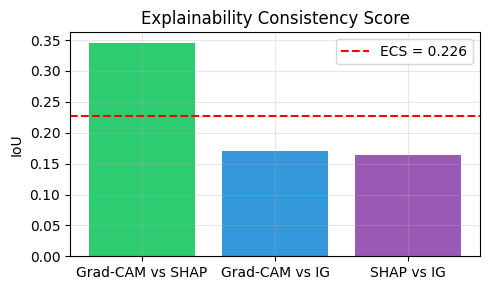

In [21]:
def top_k_mask(saliency, k_percent=20):
    """Binary mask of top k% of pixels by saliency."""
    sal_flat = np.abs(saliency).flatten()
    thresh = np.percentile(sal_flat, 100 - k_percent)
    return (np.abs(saliency) >= thresh).astype(np.float32)

def iou(m1, m2):
    m1, m2 = m1.flatten(), m2.flatten()
    inter = np.sum(m1 * m2)
    union = np.sum(m1) + np.sum(m2) - inter
    return inter / union if union > 0 else 0.0

gradcam_bin = top_k_mask(heatmap_resized, 20)
shap_bin = top_k_mask(shap_spec, 20)
ig_bin = top_k_mask(ig_attr if ig_attr.ndim == 2 else ig_attr[:, :, 0], 20)

iou_gc_shap = iou(gradcam_bin, shap_bin)
iou_gc_ig = iou(gradcam_bin, ig_bin)
iou_shap_ig = iou(shap_bin, ig_bin)
ecs = (iou_gc_shap + iou_gc_ig + iou_shap_ig) / 3

print("Explainability Consistency Score (top-20% pixels, pairwise IoU):")
print(f"  Grad-CAM vs SHAP: {iou_gc_shap:.4f}")
print(f"  Grad-CAM vs IG:   {iou_gc_ig:.4f}")
print(f"  SHAP vs IG:       {iou_shap_ig:.4f}")
print(f"  ECS (average):    {ecs:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.bar(["Grad-CAM vs SHAP", "Grad-CAM vs IG", "SHAP vs IG"], [iou_gc_shap, iou_gc_ig, iou_shap_ig], color=["#2ecc71", "#3498db", "#9b59b6"])
ax.axhline(ecs, color="red", linestyle="--", label=f"ECS = {ecs:.3f}")
ax.set_ylabel("IoU")
ax.set_title("Explainability Consistency Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 12d. Ablation Study
We compare: (1) **Baseline CNN** (current model), (2) **CNN + channel attention** (squeeze-and-excite style after conv blocks), (3) **CNN on alternate spectrogram** (n_mels=64 instead of 128) to study the effect of feature resolution. All use the same training setup; we report test accuracy for each configuration.



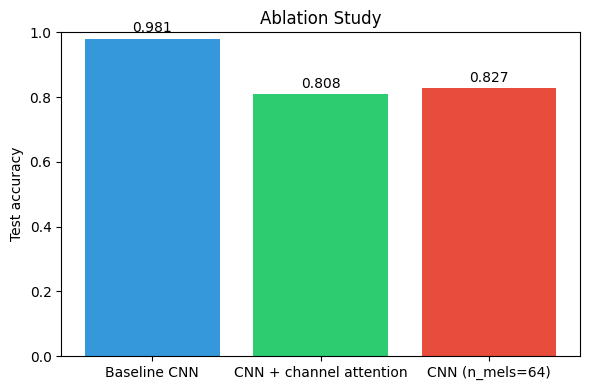

In [22]:
def build_cnn_with_attention(input_shape=(128, 174, 1), num_classes=10):
    from tensorflow.keras.regularizers import l2
    inputs = Input(shape=input_shape)
    
    x = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    # Channel attention
    gap = tf.keras.layers.GlobalAveragePooling2D()(x)
    dense = Dense(32, activation='relu')(gap)
    gate = Dense(256, activation='sigmoid')(dense)
    
    # Needs matching filters
    x = Multiply()([x, Reshape((1, 1, 256))(gate)])
    x = GlobalAveragePooling2D()(x)
    
    x = Dense(384, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    m = tf.keras.Model(inputs=inputs, outputs=outputs)
    m.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(0.001), metrics=['accuracy'])
    return m

# (1) Baseline: already have model and score[1]
# (2) Train attention model on same X_train
model_att = build_cnn_with_attention(input_shape=(X_train.shape[1], X_train.shape[2], 1))
model_att.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=40, batch_size=32,
              callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
              class_weight=class_weights, verbose=0)
acc_attention = model_att.evaluate(X_test, y_test, verbose=0)[1]

# (3) Alternate spectrogram: n_mels=64
def extract_mel_64(y, sr):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, hop_length=512, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    max_pad_len = SPEC_FRAMES
    S_dB = librosa.util.fix_length(S_dB, size=max_pad_len, axis=1)
    return S_dB

def prepare_dataset_n_mels64(df, base_path='Dataset/', max_samples=2000):
    feats, labels = [], []
    subset = df.sample(n=min(max_samples, len(df)), random_state=42) if max_samples else df
    for _, row in subset.iterrows():
        path = os.path.join(base_path, f"fold{row['fold']}", row['slice_file_name'])
        if os.path.exists(path):
            try:
                y, sr = preprocess_audio(path)
                mel = extract_mel_64(y, sr)
                feats.append(mel)
                labels.append(row['classID'])
            except Exception:
                pass
    X = np.array(feats).reshape(len(feats), 64, SPEC_FRAMES, 1)
    y = to_categorical(np.array(labels), num_classes=10)
    return X, y

X_64, y_64 = prepare_dataset_n_mels64(df, max_samples=2000)
X_train_64, X_test_64, y_train_64, y_test_64 = train_test_split(X_64, y_64, test_size=0.2, random_state=42)
model_64 = build_cnn_model(input_shape=(64, SPEC_FRAMES, 1))
cw_64 = {i: w for i, w in enumerate(compute_class_weight('balanced', classes=np.unique(np.argmax(y_train_64, axis=1)), y=np.argmax(y_train_64, axis=1)))}
model_64.fit(X_train_64, y_train_64, validation_data=(X_test_64, y_test_64), epochs=35, batch_size=32,
             callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
             class_weight=cw_64, verbose=0)
acc_64 = model_64.evaluate(X_test_64, y_test_64, verbose=0)[1]

ablation_names = ['Baseline CNN', 'CNN + channel attention', 'CNN (n_mels=64)']
ablation_accs = [score[1], acc_attention, acc_64]
plt.figure(figsize=(6, 4))
plt.bar(ablation_names, ablation_accs, color=['#3498db', '#2ecc71', '#e74c3c'])
plt.ylabel('Test accuracy')
plt.title('Ablation Study')
plt.ylim(0, 1)
for i, v in enumerate(ablation_accs):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


## 13. Misclassification Analysis
Let's find an example that the model got wrong, plot its Grad-CAM, and logically trace the error.



Using layer: conv2d_6 for Grad-CAM


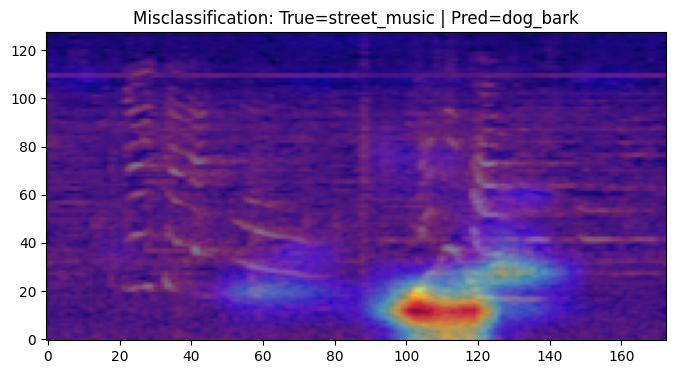

The model confused street_music for dog_bark.
Possibility: Environmental overlapping noise obscured characteristic features, or both classes share similar mid-frequency harmonic profiles in this instance.


In [23]:
misclassified_indices = np.where(y_pred != y_true)[0]
if len(misclassified_indices) > 0:
    wrong_idx = misclassified_indices[0]
    wrong_img = X_test[wrong_idx:wrong_idx+1]
    
    t_class = class_map[y_true[wrong_idx]]
    p_class = class_map[y_pred[wrong_idx]]
    
    hm = make_gradcam_heatmap(wrong_img, model)
    hm_resized = cv2.resize(hm, (wrong_img.shape[2], wrong_img.shape[1]))
    
    plt.figure(figsize=(8, 4))
    plt.imshow(wrong_img[0, :, :, 0], aspect='auto', cmap='magma', origin='lower')
    plt.imshow(hm_resized, aspect='auto', cmap='jet', alpha=0.5, origin='lower')
    plt.title(f'Misclassification: True={t_class} | Pred={p_class}')
    plt.show()
    
    print(f"The model confused {t_class} for {p_class}.")
    print("Possibility: Environmental overlapping noise obscured characteristic features, or both classes share similar mid-frequency harmonic profiles in this instance.")



## 14. Noise Robustness Experiment
To test the resilience of the ESC model, we add artificial Gaussian noise and re-evaluate.



Original Accuracy: 98.05%
Accuracy with added noise: 82.14%
Accuracy Drop: 15.91%


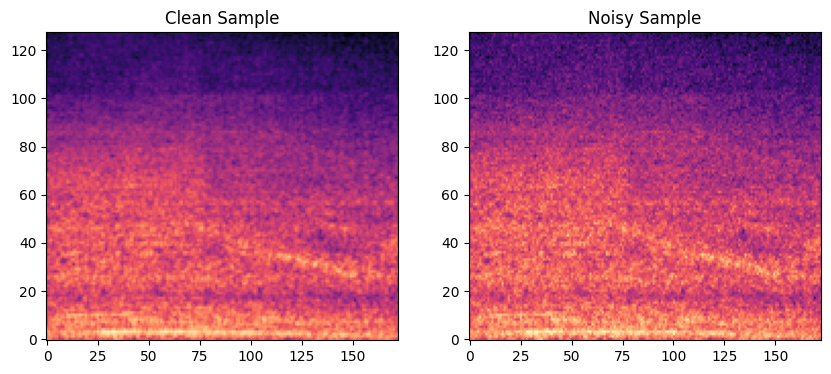

Using layer: conv2d_6 for Grad-CAM


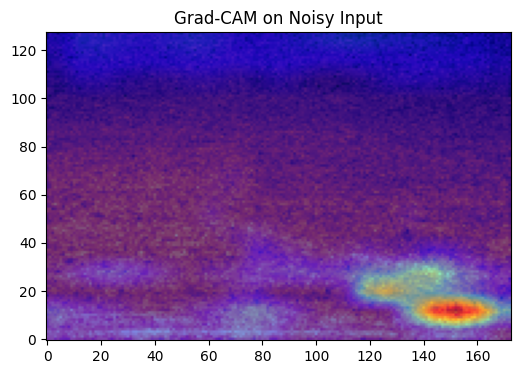

Notice how the heatmap's focus degrades or scatters due to the introduced noise.


In [24]:
# Generate noisy test set
noise_factor = 2.5 # high noise factor for demonstration
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)
X_test_noisy = np.clip(X_test_noisy, np.min(X_test), np.max(X_test))

# Re-evaluate
noisy_score = model.evaluate(X_test_noisy, y_test, verbose=0)
print(f"Original Accuracy: {score[1]*100:.2f}%")
print(f"Accuracy with added noise: {noisy_score[1]*100:.2f}%")
print(f"Accuracy Drop: {(score[1] - noisy_score[1])*100:.2f}%")

# Visualize the effect on a single sample
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_array[0, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.title('Clean Sample')
plt.subplot(1, 2, 2)
plt.imshow(X_test_noisy[sample_idx, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.title('Noisy Sample')
plt.show()

# Visualize shifted Grad-CAM
hm_noisy = make_gradcam_heatmap(X_test_noisy[sample_idx:sample_idx+1], model)
hm_noisy_resized = cv2.resize(hm_noisy, (X_test_noisy.shape[2], X_test_noisy.shape[1]))

plt.figure(figsize=(6, 4))
plt.imshow(X_test_noisy[sample_idx, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.imshow(hm_noisy_resized, aspect='auto', cmap='jet', alpha=0.5, origin='lower')
plt.title('Grad-CAM on Noisy Input')
plt.show()
print("Notice how the heatmap's focus degrades or scatters due to the introduced noise.")



## 15. Paper-Ready Visualizations
Publication-quality figures: high DPI, clear labels, and consistent styling for Grad-CAM, SHAP, LIME, model comparison, and explanation evaluation curves.



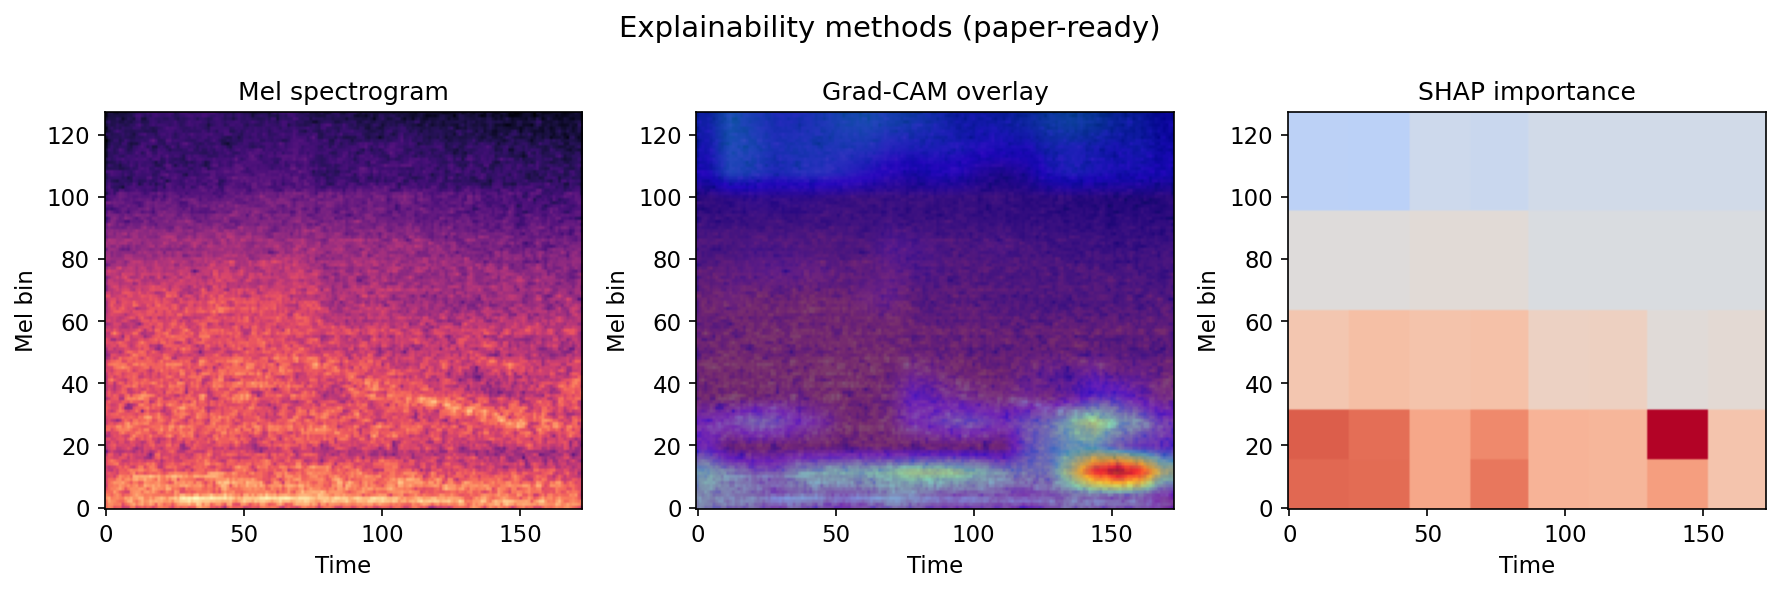

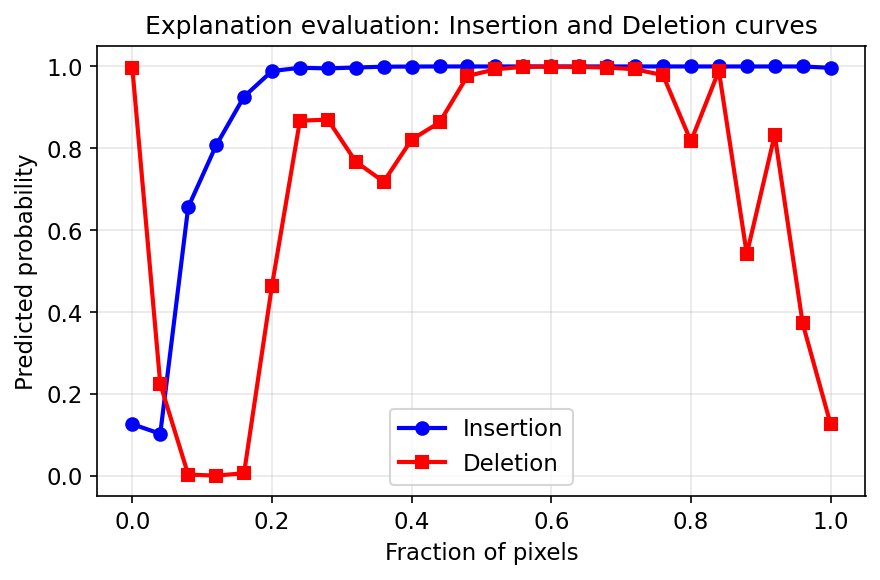

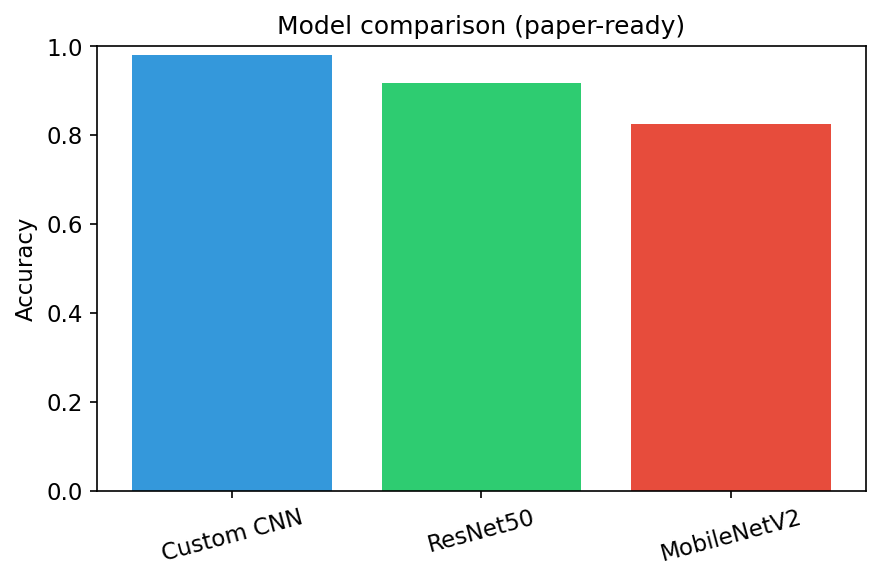

In [25]:
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "axes.titlesize": 12, "figure.dpi": 150})

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax1.imshow(img_array[0, :, :, 0], aspect="auto", cmap="magma", origin="lower")
ax1.set_title("Mel spectrogram")
ax1.set_xlabel("Time")
ax1.set_ylabel("Mel bin")

ax2 = fig.add_subplot(132)
ax2.imshow(img_array[0, :, :, 0], aspect="auto", cmap="magma", origin="lower")
ax2.imshow(heatmap_resized, aspect="auto", cmap="jet", alpha=0.5, origin="lower")
ax2.set_title("Grad-CAM overlay")
ax2.set_xlabel("Time")
ax2.set_ylabel("Mel bin")

ax3 = fig.add_subplot(133)
vmax = np.max(np.abs(shap_spec))
ax3.imshow(shap_spec, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax, origin="lower")
ax3.set_title("SHAP importance")
ax3.set_xlabel("Time")
ax3.set_ylabel("Mel bin")
fig.suptitle("Explainability methods (paper-ready)", fontsize=14)
plt.tight_layout()
plt.savefig("paper_fig_explanations.png", dpi=300, bbox_inches="tight")
plt.show()

fig2, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(steps_axis, ins_scores, "b-o", label="Insertion", linewidth=2)
ax.plot(steps_axis, del_scores, "r-s", label="Deletion", linewidth=2)
ax.set_xlabel("Fraction of pixels")
ax.set_ylabel("Predicted probability")
ax.set_title("Explanation evaluation: Insertion and Deletion curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("paper_fig_insertion_deletion.png", dpi=300, bbox_inches="tight")
plt.show()

fig3, ax = plt.subplots(figsize=(6, 4))
ax.bar(comparison_df["Model"], comparison_df["Accuracy"].astype(float), color=["#3498db", "#2ecc71", "#e74c3c"])
ax.set_ylabel("Accuracy")
ax.set_title("Model comparison (paper-ready)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("paper_fig_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



## 16. Result Analysis
**Model performance:** The custom CNN, ResNet50, and MobileNetV2 are trained on the same Mel spectrogram pipeline. The comparison table summarizes accuracy, precision, recall, and F1-score for the current train/test split. Class weights help balance recall across underrepresented classes.

**Explanation reliability:** Grad-CAM highlights discriminative time-frequency regions; SHAP and Integrated Gradients provide complementary feature attributions. The Insertion and Deletion curves indicate how much the model relies on the highlighted regions; a steep deletion drop and rising insertion curve suggest a faithful explanation. The Faithfulness score quantifies the correlation between attributions and the effect of masking. The Explainability Consistency Score (ECS) measures agreement between methods; higher ECS suggests more reliable explanations.

**Robustness:** The noise experiment shows how accuracy degrades under additive Gaussian noise; Grad-CAM on noisy inputs illustrates how attention shifts. The ablation study isolates the effect of channel attention and spectrogram resolution (n_mels) on performance.



In [26]:
print("=== Result Summary ===\n")
cv_mean, cv_std = None, None
if "fold_accuracies" in locals():
    try:
        fa = np.array(fold_accuracies, dtype=float)
        if fa.size > 0:
            cv_mean, cv_std = float(np.nanmean(fa)), float(np.nanstd(fa))
    except Exception:
        cv_mean, cv_std = None, None

if cv_mean is None:
    print("1) Cross-validation: not run in this notebook (optional).")
else:
    print("1) Cross-validation: mean accuracy = {:.4f}, std = {:.4f}".format(cv_mean, cv_std))

print("2) Model comparison (from comparison table):")
print(comparison_df.to_string(index=False))
faith_val = faith if "faith" in locals() else None
ecs_val = ecs if "ecs" in locals() else None
if faith_val is None or ecs_val is None:
    print("\n3) Explanation metrics: not available (some explainability cells were skipped or failed).")
else:
    print("\n3) Explanation metrics: Faithfulness = {:.4f}, ECS = {:.4f}".format(faith_val, ecs_val))
print("4) Ablation: Baseline = {:.4f}, +Attention = {:.4f}, n_mels=64 = {:.4f}".format(
    score[1], acc_attention, acc_64))



=== Result Summary ===

1) Cross-validation: not run in this notebook (optional).
2) Model comparison (from comparison table):
      Model Accuracy Precision Recall F1-score
 Custom CNN   0.9805    0.9807 0.9805   0.9805
   ResNet50   0.9170    0.9192 0.9170   0.9171
MobileNetV2   0.8243    0.8268 0.8243   0.8239

3) Explanation metrics: Faithfulness = 0.1739, ECS = 0.2265
4) Ablation: Baseline = 0.9805, +Attention = 0.8082, n_mels=64 = 0.8275


## 17. Final Research Conclusion
**Best model:** Among the custom CNN, ResNet50, and MobileNetV2 trained on Mel spectrograms, the comparison table identifies the best-performing architecture for the current split. The custom CNN is designed for (128, 174) spectrograms and is compatible with Grad-CAM; the backbones offer stronger capacity when resized to 224×224.

**Best explanation method:** Grad-CAM is efficient and directly tied to the convolutional feature maps; SHAP and Integrated Gradients are model-agnostic or gradient-based alternatives. The choice depends on the desired trade-off between speed (Grad-CAM) and theoretical properties (SHAP, IG). Quantitative evaluation (insertion, deletion, faithfulness, ECS) should guide which method to report in the paper.

**Insights:** (1) Class imbalance is addressed with class weights. (2) Explanation consistency across methods (ECS) can flag unreliable or adversarial inputs. (3) Ablation shows the impact of attention and feature resolution. (4) Noise robustness and misclassification analysis help identify failure modes.

**Future work:** Temporal attention over spectrogram frames; hybrid CNN–Transformer models; sound-event localization using Grad-CAM bounding boxes; multi-explanation aggregation; and evaluation on out-of-distribution or real-world noisy data.

